In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/AIKONIC-AI/PHASE_02

import sys, os
import numpy as np
import tensorflow as tf
from pathlib import Path
from collections import defaultdict

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import config
from data_loader import DataLoader

# Load Data and Model
loader = DataLoader()
X_test, y_test, test_paths = loader.get_arrays("test", return_paths=True)

print("Loading Production Model...")
prod_model = tf.keras.models.load_model(config.CHECKPOINT_PROD_KERAS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/AIKONIC-AI/PHASE_02
Loading Production Model...


6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step

 📊 TEST SET PERFORMANCE SUMMARY
  Metric          | Patch-Level     | Patient-Level
-------------------------------------------------------
  ACCURACY        | 0.8199          | 0.7949
  PRECISION       | 0.8294          | 0.7937
  RECALL          | 0.8107          | 0.7937
  F1-SCORE        | 0.8143          | 0.7937
  AUC-ROC         | 0.9120          | 0.9021
Total Patients Evaluated: 39



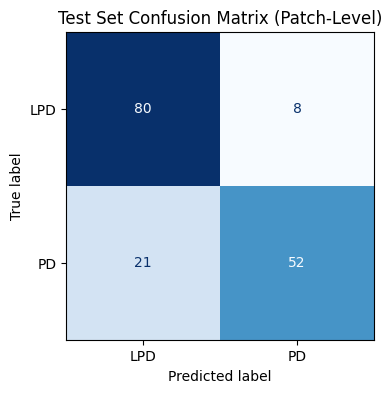

In [ ]:
# Patch-Level & Patient-Level Inference
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from collections import defaultdict
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import config

y_pred_probs = prod_model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred_pd_prob = y_pred_probs[:, 1]

# 1. Patch-Level Metrics
patch_acc = accuracy_score(y_test, y_pred)
patch_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
patch_sens = recall_score(y_test, y_pred, average='macro', zero_division=0)
patch_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
patch_auroc = roc_auc_score(y_test, y_pred_pd_prob)

# 2. Patient-Level Majority Voting Logic
patient_predictions = defaultdict(list)
patient_probs = defaultdict(list)
patient_true_labels = {}

# Group predictions and probabilities by Patient ID
for path, true_label, pred, prob in zip(test_paths, y_test, y_pred, y_pred_pd_prob):
    raw_name = Path(path).stem.split('_p')[0]
    patient_predictions[raw_name].append(pred)
    patient_probs[raw_name].append(prob)
    patient_true_labels[raw_name] = true_label

y_patient_true = []
y_patient_pred = []
y_patient_prob = []

for raw_name in patient_predictions.keys():
    preds = patient_predictions[raw_name]
    probs = patient_probs[raw_name]
    true_label = patient_true_labels[raw_name]

    # Majority Voting: If 50% or more patches are predicted as PD (1), classify patient as PD
    votes_for_pd = sum(preds)
    final_diagnosis = 1 if votes_for_pd >= (len(preds) / 2) else 0

    y_patient_true.append(true_label)
    y_patient_pred.append(final_diagnosis)
    # Average the patch probabilities to get a patient-level probability for AUC
    y_patient_prob.append(np.mean(probs))

# 3. Patient-Level Metrics
patient_acc = accuracy_score(y_patient_true, y_patient_pred)
patient_prec = precision_score(y_patient_true, y_patient_pred, average='macro', zero_division=0)
patient_sens = recall_score(y_patient_true, y_patient_pred, average='macro', zero_division=0)
patient_f1 = f1_score(y_patient_true, y_patient_pred, average='macro', zero_division=0)
patient_auroc = roc_auc_score(y_patient_true, y_patient_prob)

# 4. Display Formatted Results
display_metrics = {
    "ACCURACY": (patch_acc, patient_acc),
    "PRECISION": (patch_prec, patient_prec),
    "RECALL": (patch_sens, patient_sens),
    "F1-SCORE": (patch_f1, patient_f1),
    "AUC-ROC": (patch_auroc, patient_auroc)
}

print("\n" + "="*55)
print(" TEST SET PERFORMANCE SUMMARY")
print("="*55)
print(f"  {'Metric':<15} | {'Patch-Level':<15} | {'Patient-Level'}")
print("-" * 55)

for name, (patch_val, patient_val) in display_metrics.items():
    print(f"  {name:<15} | {patch_val:<15.4f} | {patient_val:.4f}")

print("="*55)
print(f"Total Patients Evaluated: {len(patient_predictions)}\n")

# 5. Generate & Save Visuals
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=config.CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Test Set Confusion Matrix (Patch-Level)")
plt.savefig(os.path.join(config.EVAL_DIR, "confusion_matrix.png"), dpi=120, bbox_inches="tight")
plt.show()